Nettoyage  du tableau des expéditions 1983–1987 pour avoir un DataFrame clair (Date, Shipments, ConsumerPacks, DealerAllowances):

In [ ]:
import sys
!{sys.executable} -m pip install pandas




[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import sys
!{sys.executable} -m pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.6 MB 5.9 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.6 MB 5.7 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.6 MB 5.8 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.6 MB 5.8 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 5.8 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.6 MB 5.9 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.6 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 5.8 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- --


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Reload raw CSV without header to parse properly
import pandas as pd

csv_path = "Harmon_Foods_data.csv"
raw = pd.read_csv(csv_path, header=None)



In [9]:
# Extract the block starting at row index=2 (Month, Case Shipments, Consumer Packs, Dealer Allowance)
table = raw.iloc[2:, [0,1,2,3]].copy()
table.columns = ["Month", "Shipments", "ConsumerPacks", "DealerAllowances"]

# Stop extraction at the first blank after 1987 (Month becomes NaN)
table = table[table["Month"].notna()]



In [10]:
# Clean numbers
for c in ["Shipments","ConsumerPacks","DealerAllowances"]:
    table[c] = pd.to_numeric(table[c], errors="coerce")

# Parse month-year to datetime
table["Date"] = pd.to_datetime(table["Month"], format="%b-%y", errors="coerce")

# Keep only valid dates
df_clean = table.dropna(subset=["Date"])[["Date","Shipments","ConsumerPacks","DealerAllowances"]].reset_index(drop=True)




In [11]:
df_clean.head(15)

,Date,Shipments,ConsumerPacks,DealerAllowances
0,1983-01-01,NaN,0.0,396776.0
1,1983-02-01,NaN,0.0,152296.0
2,1983-03-01,NaN,0.0,157640.0
3,1983-04-01,NaN,0.0,246064.0
4,1983-05-01,NaN,15012.0,335716.0
5,1983-06-01,NaN,62337.0,326312.0
6,1983-07-01,NaN,4022.0,263284.0
7,1983-08-01,NaN,3130.0,488676.0
8,1983-09-01,NaN,422.0,33928.0
9,1983-10-01,NaN,0.0,224028.0


 # Tendance globale des expéditions mensuelles.:

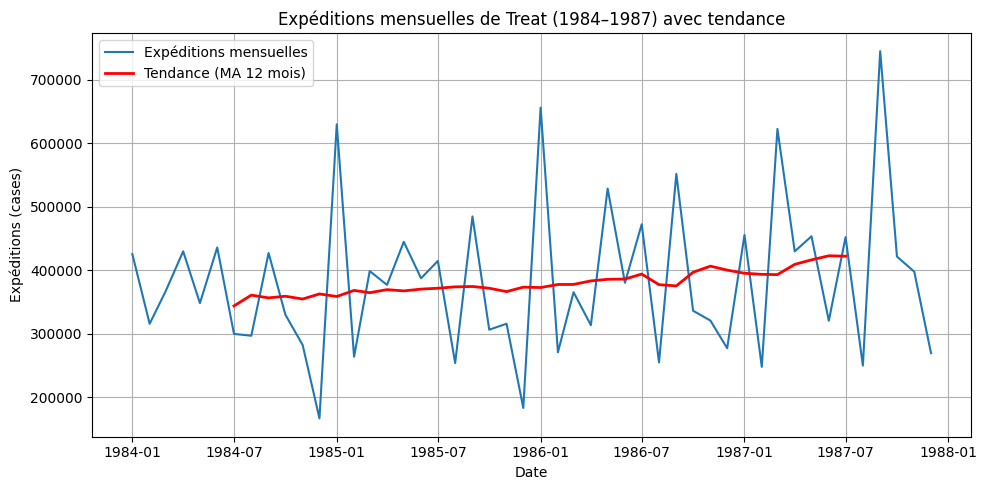

Date
1     541340.25
2     274206.25
3     438217.00
4     387116.75
5     443411.00
6     380618.50
7     409388.50
8     263499.00
9     551750.75
10    348180.75
11    328741.25
12    223793.00
Name: Shipments, dtype: float64

In [12]:
import matplotlib.pyplot as plt

# On garde seulement les années complètes avec Shipments (1984–1987)
df_sub = df_clean[df_clean["Date"].dt.year >= 1984].copy()

# Calcul moyenne mobile 12 mois (tendance)
df_sub["Trend_MA12"] = df_sub["Shipments"].rolling(window=12, center=True).mean()

# Graphique expéditions + tendance
plt.figure(figsize=(10,5))
plt.plot(df_sub["Date"], df_sub["Shipments"], label="Expéditions mensuelles")
plt.plot(df_sub["Date"], df_sub["Trend_MA12"], color="red", linewidth=2, label="Tendance (MA 12 mois)")
plt.title("Expéditions mensuelles de Treat (1984–1987) avec tendance")
plt.xlabel("Date")
plt.ylabel("Expéditions (cases)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Regrouper par mois pour observer saisonnalité moyenne
seasonality = df_sub.groupby(df_sub["Date"].dt.month)["Shipments"].mean()

seasonality


# Dé-saisonnaliser les expéditions mensuelles 

In [13]:
import numpy as np

# Recalculer la tendance par moyenne mobile 12 mois (centre)
df_sub["MA12"] = df_sub["Shipments"].rolling(window=12, center=True).mean()

# Ratio Shipments / Trend pour estimer saisonnalité
df_sub["Ratio"] = df_sub["Shipments"] / df_sub["MA12"]

# Moyenne des ratios par mois
seasonal_idx = df_sub.groupby(df_sub["Date"].dt.month)["Ratio"].mean()

# Normalisation (moyenne = 1)
seasonal_idx = seasonal_idx / seasonal_idx.mean()

# Désaisonnalisation
df_sub["Deseasonalized"] = df_sub.apply(
    lambda row: row["Shipments"] / seasonal_idx.loc[row["Date"].month]
    if not np.isnan(row["Shipments"]) else np.nan,
    axis=1
)

# Résultats des indices saisonniers
seasonal_idx.round(2)


Date
1     1.57
2     0.69
3     1.22
4     0.97
5     1.23
6     0.94
7     1.07
8     0.73
9     1.33
10    0.87
11    0.82
12    0.55
Name: Ratio, dtype: float64

# Graphe comparatif entre serie saisonnalisé et désaisonnalisé

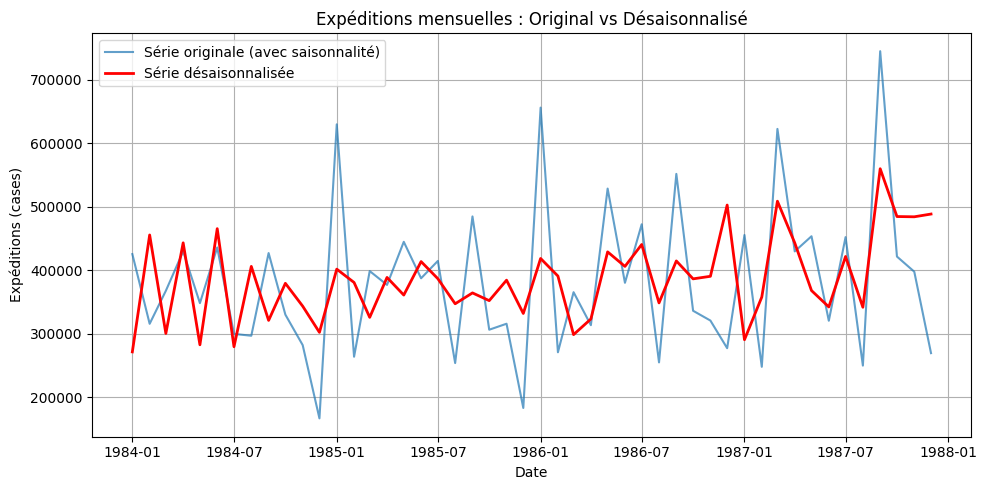

In [14]:
import matplotlib.pyplot as plt

# Recompute indices saisonniers and désaisonnalisation (assure les données sont là)
df_sub["MA12"] = df_sub["Shipments"].rolling(window=12, center=True).mean()
df_sub["Ratio"] = df_sub["Shipments"] / df_sub["MA12"]
seasonal_idx = df_sub.groupby(df_sub["Date"].dt.month)["Ratio"].mean()
seasonal_idx = seasonal_idx / seasonal_idx.mean()

df_sub["Deseasonalized"] = df_sub.apply(
    lambda row: row["Shipments"] / seasonal_idx.loc[row["Date"].month]
    if not np.isnan(row["Shipments"]) else np.nan,
    axis=1
)

# Tracé comparatif
plt.figure(figsize=(10,5))
plt.plot(df_sub["Date"], df_sub["Shipments"], label="Série originale (avec saisonnalité)", alpha=0.7)
plt.plot(df_sub["Date"], df_sub["Deseasonalized"], label="Série désaisonnalisée", color="red", linewidth=2)
plt.title("Expéditions mensuelles : Original vs Désaisonnalisé")
plt.xlabel("Date")
plt.ylabel("Expéditions (cases)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Création des variables décalées (lags 0,1,2) pour ConsumerPacks et DealerAllowances

In [15]:
# Créer variables décalées (lags 0,1,2) pour ConsumerPacks et DealerAllowances
for var in ["ConsumerPacks","DealerAllowances"]:
    for lag in range(0,3):
        df_sub[f"{var}_lag{lag}"] = df_sub[var].shift(lag)

# Aperçu des nouvelles colonnes
df_sub[["Date","Shipments","ConsumerPacks","ConsumerPacks_lag0","ConsumerPacks_lag1","ConsumerPacks_lag2",
        "DealerAllowances","DealerAllowances_lag0","DealerAllowances_lag1","DealerAllowances_lag2"]].head(15)


,Date,Shipments,ConsumerPacks,ConsumerPacks_lag0,ConsumerPacks_lag1,ConsumerPacks_lag2,DealerAllowances,DealerAllowances_lag0,DealerAllowances_lag1,DealerAllowances_lag2
12,1984-01-01,425075.0,75253.0,75253.0,NaN,NaN,457732.0,457732.0,NaN,NaN
13,1984-02-01,315305.0,15036.0,15036.0,75253.0,NaN,254396.0,254396.0,457732.0,NaN
14,1984-03-01,367286.0,134440.0,134440.0,15036.0,75253.0,259952.0,259952.0,254396.0,457732.0
15,1984-04-01,429432.0,119740.0,119740.0,134440.0,15036.0,267368.0,267368.0,259952.0,254396.0
16,1984-05-01,347874.0,135590.0,135590.0,119740.0,134440.0,158504.0,158504.0,267368.0,259952.0
17,1984-06-01,435529.0,189639.0,189639.0,135590.0,119740.0,430012.0,430012.0,158504.0,267368.0
18,1984-07-01,299403.0,9308.0,9308.0,189639.0,135590.0,388516.0,388516.0,430012.0,158504.0
19,1984-08-01,296505.0,41099.0,41099.0,9308.0,189639.0,225616.0,225616.0,388516.0,430012.0
20,1984-09-01,426701.0,9391.0,9391.0,41099.0,9308.0,1042304.0,1042304.0,225616.0,388516.0
21,1984-10-01,329722.0,942.0,942.0,9391.0,41099.0,974092.0,974092.0,1042304.0,225616.0


# .

In [16]:
# Calculer la matrice de corrélation pour Shipments, Consumer Packs, Dealer Allowances et leurs lags
corr_vars = [
    "Shipments",
    "ConsumerPacks","ConsumerPacks_lag0","ConsumerPacks_lag1","ConsumerPacks_lag2",
    "DealerAllowances","DealerAllowances_lag0","DealerAllowances_lag1","DealerAllowances_lag2"
]

corr_matrix = df_sub[corr_vars].corr()

corr_matrix.round(2)


,Shipments,ConsumerPacks,ConsumerPacks_lag0,ConsumerPacks_lag1,ConsumerPacks_lag2,DealerAllowances,DealerAllowances_lag0,DealerAllowances_lag1,DealerAllowances_lag2
Shipments,1.00,0.49,0.49,-0.33,0.09,0.54,0.54,0.00,0.04
ConsumerPacks,0.49,1.00,1.00,-0.04,-0.21,-0.24,-0.24,-0.19,0.26
ConsumerPacks_lag0,0.49,1.00,1.00,-0.04,-0.21,-0.24,-0.24,-0.19,0.26
ConsumerPacks_lag1,-0.33,-0.04,-0.04,1.00,-0.03,-0.12,-0.12,-0.24,-0.19
ConsumerPacks_lag2,0.09,-0.21,-0.21,-0.03,1.00,0.33,0.33,-0.12,-0.23
DealerAllowances,0.54,-0.24,-0.24,-0.12,0.33,1.00,1.00,-0.04,-0.13
DealerAllowances_lag0,0.54,-0.24,-0.24,-0.12,0.33,1.00,1.00,-0.04,-0.13
DealerAllowances_lag1,0.00,-0.19,-0.19,-0.24,-0.12,-0.04,-0.04,1.00,-0.04
DealerAllowances_lag2,0.04,0.26,0.26,-0.19,-0.23,-0.13,-0.13,-0.04,1.00


# prediction pour l'annee 1988

In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# --- Charger et préparer ---
df_raw = pd.read_csv("Harmon_Foods_data.csv", header=None)

tbl = df_raw.iloc[2:, [0,1,2,3]].copy()
tbl.columns = ["Month", "Shipments", "ConsumerPacks", "DealerAllowances"]
tbl = tbl[tbl["Month"].notna()].copy()

# Coercition numérique stricte
for c in ["Shipments","ConsumerPacks","DealerAllowances"]:
    tbl[c] = pd.to_numeric(tbl[c], errors="coerce")

tbl["Date"] = pd.to_datetime(tbl["Month"], format="%b-%y", errors="coerce")
df = tbl.dropna(subset=["Date"])[["Date","Shipments","ConsumerPacks","DealerAllowances"]].reset_index(drop=True)
df = df[df["Date"].dt.year >= 1984].set_index("Date").sort_index()

# --- Features (t, dummies mois, lags) ---
df["t"] = np.arange(1, len(df)+1)

dmy = pd.get_dummies(df.index.month, prefix="m")
# Janvier baseline
if "m_1" in dmy.columns:
    dmy = dmy.drop(columns="m_1")
dmy.index = df.index
df = pd.concat([df, dmy], axis=1)

for var in ["ConsumerPacks","DealerAllowances"]:
    df[f"{var}_lag0"] = df[var]
    df[f"{var}_lag1"] = df[var].shift(1)

# Supprime lignes avec NaN (causés par lag1)
df = df.dropna().copy()

# --- Matrice X/Y 100% numérique ---
month_cols = [c for c in df.columns if c.startswith("m_")]
X_cols = ["t","ConsumerPacks_lag0","ConsumerPacks_lag1","DealerAllowances_lag0","DealerAllowances_lag1"] + month_cols

# Coercition en float
df["Shipments"] = pd.to_numeric(df["Shipments"], errors="coerce")
for c in X_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

mask = df["Shipments"].notna() & df[X_cols].notna().all(axis=1)
y = df.loc[mask, "Shipments"].astype("float64")
X = df.loc[mask, X_cols].astype("float64")

Xc = sm.add_constant(X, has_constant="add")
model = sm.OLS(y, Xc).fit()
print(model.summary())

# --- Construire 1988 (promos = moyennes mensuelles historiques par défaut) ---
future_idx = pd.date_range("1988-01-01","1988-12-01", freq="MS")
fut = pd.DataFrame(index=future_idx)

for var in ["ConsumerPacks","DealerAllowances"]:
    means = df[var.replace("_lag0","")].groupby(df.index.month).mean().to_dict()
    fut[var] = [float(means.get(m, 0.0)) for m in fut.index.month]

last_t = int(df["t"].iloc[-1])
fut["t"] = np.arange(last_t+1, last_t+1+len(fut))

dmy_f = pd.get_dummies(fut.index.month, prefix="m")
if "m_1" in dmy_f.columns:
    dmy_f = dmy_f.drop(columns="m_1")
dmy_f.index = fut.index
fut = pd.concat([fut, dmy_f], axis=1)

for var in ["ConsumerPacks","DealerAllowances"]:
    fut[f"{var}_lag0"] = fut[var]
    combo = pd.concat([df[[var.replace("_lag0","")]], fut[[var]]], axis=0)
    fut[f"{var}_lag1"] = combo[var].shift(1).loc[fut.index]

# S’assurer que les colonnes de 1988 correspondent EXACTEMENT à celles du modèle
for c in X_cols:
    if c not in fut.columns:
        fut[c] = 0.0

X_future = fut[X_cols].astype("float64")
Xf = sm.add_constant(X_future, has_constant="add")

forecast = model.predict(Xf).round(0).astype(int)
print("\nPrévisions 1988 (Shipments) :")
print(forecast)

# Optionnel : tableau récap
out = pd.DataFrame({
    "Forecast_Shipments": forecast,
    "ConsumerPacks_plan": fut["ConsumerPacks_lag0"],
    "DealerAllowances_plan": fut["DealerAllowances_lag0"],
})
print("\nTableau prévision + plans promos (par mois 1988) :")
print(out)
out.to_csv("Harmon_1988_forecast.csv")
print("\nExporté : Harmon_1988_forecast.csv")


                            OLS Regression Results                            
Dep. Variable:              Shipments   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     22.11
Date:                Fri, 08 May 2026   Prob (F-statistic):           2.49e-12
Time:                        14:05:06   Log-Likelihood:                -556.86
No. Observations:                  47   AIC:                             1148.
Df Residuals:                      30   BIC:                             1179.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  3.909e+

In [ ]:
# Final attempt: compute month numbers robustly and build+export the table

import pandas as pd
import numpy as np
#from caas_jupyter_tools import display_dataframe_to_user

# Reload preprocessed parts quickly
raw = pd.read_csv("Harmon_Foods_data.csv", header=None)
tbl = raw.iloc[2:, [0,1,2,3]].copy()
tbl.columns = ["Month", "Shipments", "ConsumerPacks", "DealerAllowances"]
tbl = tbl[tbl["Month"].notna()].copy()
for c in ["Shipments","ConsumerPacks","DealerAllowances"]:
    tbl[c] = pd.to_numeric(tbl[c], errors="coerce")
tbl["Date"] = pd.to_datetime(tbl["Month"], format="%b-%y", errors="coerce")
df = tbl.dropna(subset=["Date"])[["Date","Shipments","ConsumerPacks","DealerAllowances"]].reset_index(drop=True)
df = df[df["Date"].dt.year >= 1984].set_index("Date").sort_index()

# Features
df["t"] = np.arange(1, len(df)+1)
dmy = pd.get_dummies(df.index.month, prefix="m")
if "m_1" in dmy.columns:
    dmy = dmy.drop(columns=["m_1"])
dmy.index = df.index
df = pd.concat([df, dmy], axis=1)
for var in ["ConsumerPacks","DealerAllowances"]:
    df[f"{var}_lag0"] = df[var]
    df[f"{var}_lag1"] = df[var].shift(1)
df = df.dropna().copy()

month_cols = [c for c in df.columns if c.startswith("m_")]
X_cols = ["t","ConsumerPacks_lag0","ConsumerPacks_lag1","DealerAllowances_lag0","DealerAllowances_lag1"] + month_cols
y = df["Shipments"].astype(float).values
X = df[X_cols].astype(float).values
X_const = np.column_stack([np.ones(len(X)), X])
beta, *_ = np.linalg.lstsq(X_const, y, rcond=None)

# Future
future_idx = pd.date_range("1988-01-01", "1988-12-01", freq="MS")
fut = pd.DataFrame(index=future_idx)
for var in ["ConsumerPacks","DealerAllowances"]:
    means = df[var.replace("_lag0","")].groupby(df.index.month).mean().to_dict()
    fut[var] = [float(means.get(m, 0.0)) for m in [d.month for d in future_idx]]
last_t = int(df["t"].iloc[-1])
fut["t"] = np.arange(last_t+1, last_t+1+len(fut))

dmy_f = pd.get_dummies([d.month for d in fut.index], prefix="m")
dmy_f.index = fut.index
if "m_1" in dmy_f.columns:
    dmy_f = dmy_f.drop(columns=["m_1"])
for c in month_cols:
    if c not in dmy_f.columns:
        dmy_f[c] = 0.0
dmy_f = dmy_f[month_cols]
fut = pd.concat([fut, dmy_f], axis=1)

for var in ["ConsumerPacks","DealerAllowances"]:
    fut[f"{var}_lag0"] = fut[var]
    combo = pd.concat([df[[var.replace("_lag0","")]], fut[[var]]], axis=0)
    fut[f"{var}_lag1"] = combo[var].shift(1).loc[fut.index]

# Predict
X_future = fut[X_cols].astype(float).values
Xf_const = np.column_stack([np.ones(len(X_future)), X_future])
y_pred = Xf_const @ beta
y_pred = np.nan_to_num(y_pred, nan=np.nanmean(y)).round(0).astype(int)

month_names = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]
month_labels = [month_names[d.month-1] for d in fut.index.to_pydatetime()]

result = pd.DataFrame({
    "Mois": month_labels,
    "Shipments_prévus": y_pred,
    "ConsumerPacks_plan": fut["ConsumerPacks_lag0"].round(0).astype(int).values,
    "DealerAllowances_plan": fut["DealerAllowances_lag0"].round(0).astype(int).values,
}, index=fut.index)

out_path = "Harmon_1988_forecast_table.csv"
result.to_csv(out_path, index_label="Date")

#display_dataframe_to_user("Prévisions 1988 — Harmon Foods (table)", result)

out_path

result


,Mois,Shipments_prévus,ConsumerPacks_plan,DealerAllowances_plan
1988-01-01,Jan,593389,464431,232415
1988-02-01,Fév,278584,33195,282471
1988-03-01,Mar,458862,35782,1504648
1988-04-01,Avr,407762,42516,279204
1988-05-01,Mai,464056,123128,304546
1988-06-01,Juin,401264,95618,330566
1988-07-01,Juil,430034,106622,376311
1988-08-01,Août,284144,50755,115273
1988-09-01,Sep,572396,181937,1492677
1988-10-01,Oct,368826,63094,403123


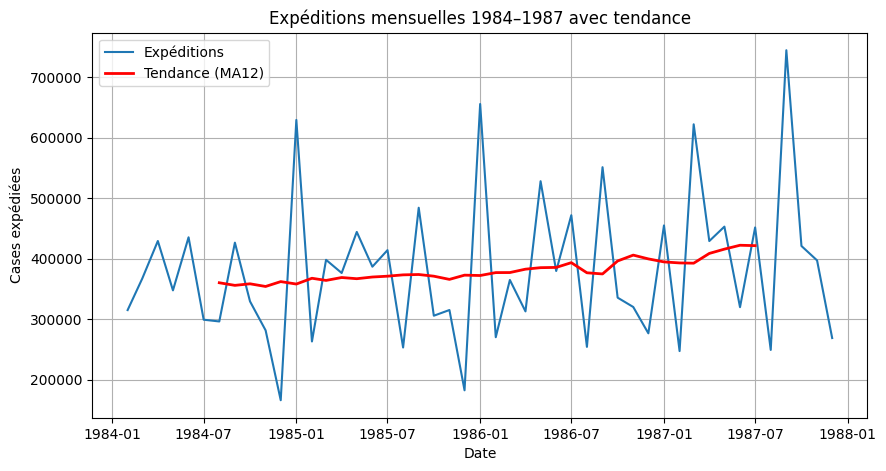

In [ ]:
import matplotlib.pyplot as plt

df_sub = df[df.index.year >= 1984].copy()
df_sub["MA12"] = df_sub["Shipments"].rolling(window=12, center=True).mean()

plt.figure(figsize=(10,5))
plt.plot(df_sub.index, df_sub["Shipments"], label="Expéditions")
plt.plot(df_sub.index, df_sub["MA12"], color="red", linewidth=2, label="Tendance (MA12)")
plt.title("Expéditions mensuelles 1984–1987 avec tendance")
plt.xlabel("Date")
plt.ylabel("Cases expédiées")
plt.legend()
plt.grid(True)
#plt.savefig("figures/tendance.png", dpi=300)  # <- Sauvegarde
plt.show()


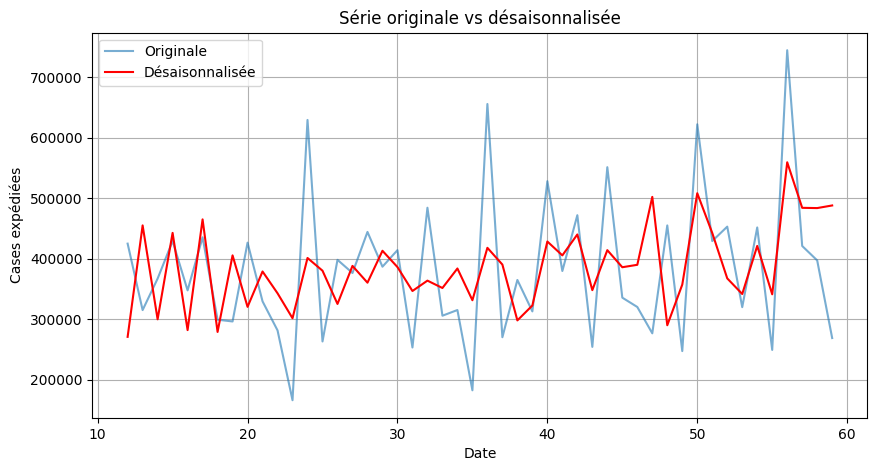

In [21]:
plt.figure(figsize=(10,5))
plt.plot(df_sub.index, df_sub["Shipments"], label="Originale", alpha=0.6)
plt.plot(df_sub.index, df_sub["Deseasonalized"], label="Désaisonnalisée", color="red")
plt.title("Série originale vs désaisonnalisée")
plt.xlabel("Date")
plt.ylabel("Cases expédiées")
plt.legend()
plt.grid(True)
plt.savefig("desaisonnalisation.png", dpi=300)
plt.show()


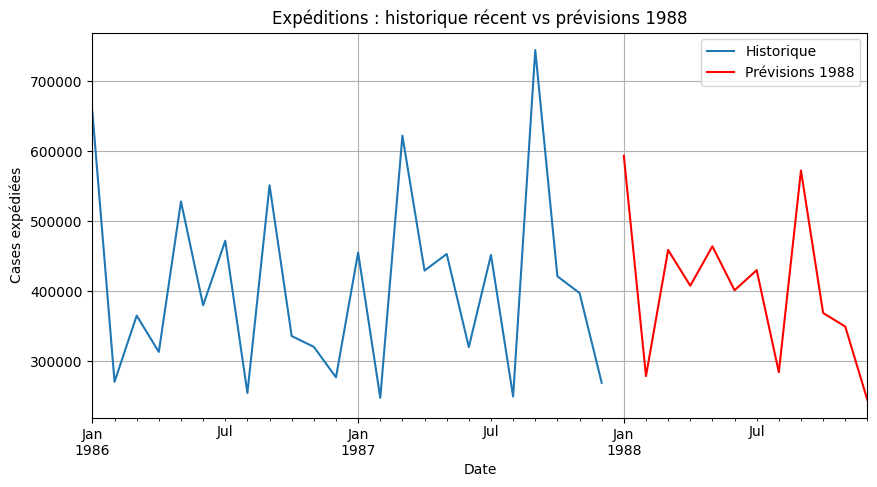

In [ ]:
plt.figure(figsize=(10,5))
df["Shipments"].loc["1986":].plot(label="Historique")
result["Shipments_prévus"].plot(label="Prévisions 1988", color="red")
plt.title("Expéditions : historique récent vs prévisions 1988")
plt.xlabel("Date")
plt.ylabel("Cases expédiées")
plt.legend()
plt.grid(True)
#plt.savefig("figures/forecast.png", dpi=300)
plt.show()


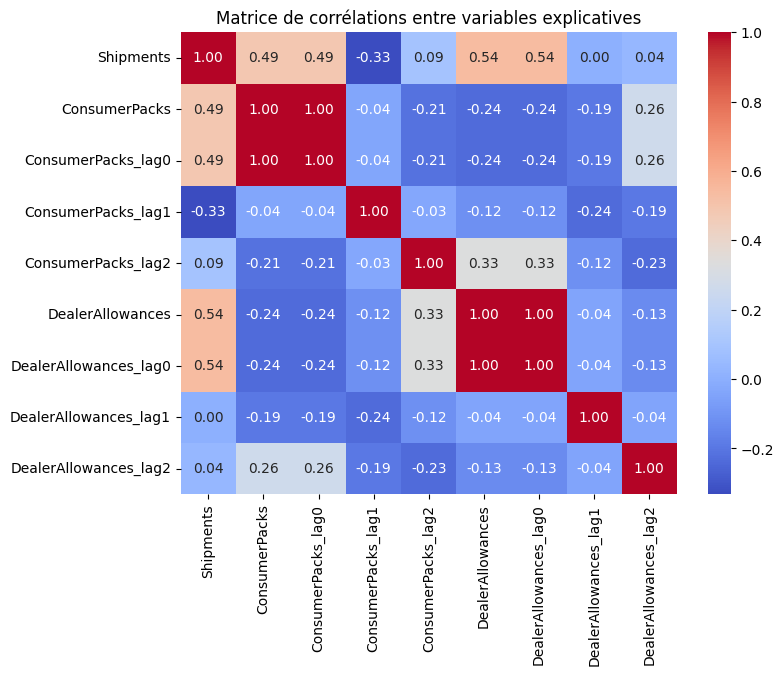

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélations entre variables explicatives")
#plt.savefig("figures/correlations.png", dpi=300)
plt.show()
